[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reinhart-group/camel-2dcc/blob/summit-menu/notebooks/python_demo.ipynb)

# Build your own widget

Every other notebook in this set is designed so nobody has to sign in. The pictures are saved,
they already respond to taps, and a phone with no Google account can use them.

**This one is the opposite, on purpose.** Sign in, press the play button on each cell, and watch
what it takes to build those widgets yourself. It is less code than you would guess. If your
students can run Python, they do not have to accept the sliders someone else chose — they can
build the ones their own question needs.

The data is real: about a thousand crystal films grown at Penn State's 2D Crystal Consortium,
with what was measured on each one.

## Setup — run this first

This installs the helper code and downloads the data. It takes about a minute, once.

In [1]:
!pip install -q "camel-2dcc @ git+https://github.com/reinhart-group/camel-2dcc@summit-menu"

DATA_URL = "https://pennstateoffice365-my.sharepoint.com/:u:/g/personal/wfr5091_psu_edu/IQCkNUoFnJNJSK8lUEepTJeSAT3NukSFJzB9-9fS5GB5mp0?e=KafIFG"

import io, json, os, shutil, zipfile, requests

def _ready():
    try:
        m = json.load(open("camel-2dcc/manifest.json"))
        return m["release_id"] == "camel-2dcc-v1" and all(
            os.path.exists("camel-2dcc/" + f["path"]) for f in m["files"])
    except (OSError, ValueError, KeyError):
        return False

if not _ready():
    shutil.rmtree("camel-2dcc", ignore_errors=True)
    r = requests.get(DATA_URL + ("&" if "?" in DATA_URL else "?") + "download=1", timeout=120)
    r.raise_for_status()
    if r.content[:2] != b"PK":
        raise RuntimeError("That download was not the data file. Check DATA_URL.")
    zipfile.ZipFile(io.BytesIO(r.content)).extractall(".")
    if not _ready():
        raise RuntimeError("The data file is incomplete or the wrong version.")

print("ready")

ready


## 1. Look at the data

Two lines. Each row is one crystal film somebody grew, and what they measured on it.

In [2]:
import pandas as pd

films = pd.read_csv("camel-2dcc/growth_summary.csv")
films.head()

,sample_id,material,growth_method,total_recipe_min,durations_complete,n_steps,growth_time_min,growth_temperature_C,growth_pressure_torr,n_growth_steps,n_recipes,rms_roughness_nm,scan_size_um
0,17207,MoS2,MOCVD,89.083,True,37,30.0,NaN,100.0,1.0,1,0.3754,5.0000
1,17224,MoS2,MOCVD,69.166,True,8,40.0,NaN,100.0,1.0,1,0.3805,5.0000
2,17391,Al2O3,MOCVD,42.000,True,5,NaN,NaN,NaN,NaN,1,0.6042,3.3398
3,17392,WSe2,MOCVD,42.000,True,5,NaN,NaN,NaN,NaN,1,NaN,NaN
4,17393,WSe2,MOCVD,62.000,True,8,NaN,NaN,NaN,NaN,1,1.0115,2.0000


## 2. One picture

One more line draws the distribution of surface roughness — how bumpy each film came out, in
nanometres. A nanometre is about four atoms across.

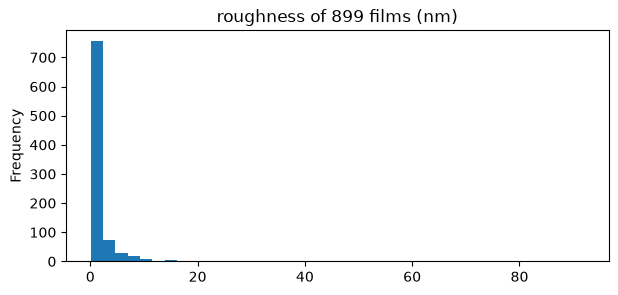

In [3]:
films["rms_roughness_nm"].plot.hist(bins=40, figsize=(7, 3),
                                    title="roughness of %d films (nm)" % films["rms_roughness_nm"].count());

That picture has a problem, and it is a good one to hand a class: almost every film is crammed
into the first bar. One film measures 92 nm while the median is 0.75, so the axis spends itself
on a handful of samples.

**This is where a slider earns its place.** Instead of arguing about the right axis, let people
move it.

## 3. One slider

`interact` turns any function into a widget. Whatever arguments you give it become controls: a
number range becomes a slider, a list becomes a dropdown, True or False becomes a checkbox.

That is the whole trick. Four lines.

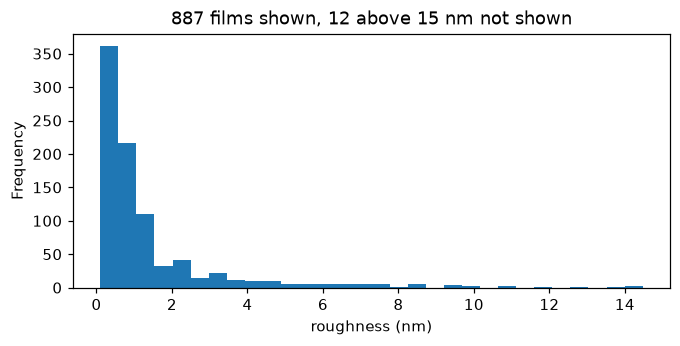

In [4]:
from ipywidgets import interact
import matplotlib.pyplot as plt

@interact(cut_off_at=(2, 92, 2), bins=(5, 60, 5))
def roughness(cut_off_at=15, bins=30):
    kept = films[films["rms_roughness_nm"] <= cut_off_at]["rms_roughness_nm"]
    hidden = films["rms_roughness_nm"].count() - kept.count()
    kept.plot.hist(bins=bins, figsize=(7, 3))
    plt.title("%d films shown, %d above %d nm not shown" % (kept.count(), hidden, cut_off_at))
    plt.xlabel("roughness (nm)")

Notice what the title does. Every time you hide part of the data, it says how much. That habit is
worth more to a statistics class than the chart is.

## 4. Rebuild one of our widgets

Item M-02 in the "find the mess" notebook asks: if you insist on rows where *everything* you need
was recorded, who survives? It matters because the answer is not the same for every group.

Here it is in about a dozen lines.

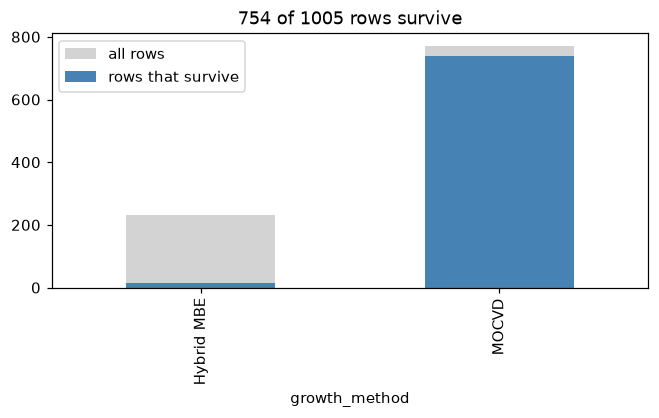

In [5]:
def survivors(need_growth_time=True, need_roughness=True):
    keep = pd.Series(True, index=films.index)
    if need_growth_time:
        keep &= films["growth_time_min"].notna()
    if need_roughness:
        keep &= films["rms_roughness_nm"].notna()

    total = films.groupby("growth_method").size()
    left = films[keep].groupby("growth_method").size().reindex(total.index, fill_value=0)

    ax = total.plot.bar(figsize=(7, 3), color="lightgrey", label="all rows")
    left.plot.bar(ax=ax, color="steelblue", label="rows that survive")
    ax.set_title("%d of %d rows survive" % (keep.sum(), len(films)))
    ax.legend()
    for method in total.index:
        print("%-12s %4d of %4d kept (%.0f%%)" % (method, left[method], total[method],
                                                  100 * left[method] / total[method]))

interact(survivors);

Untick nothing and both methods look comparable. Tick both and one of them nearly vanishes: the
records are far more complete for one growth method than the other. Any comparison built only
from "complete" rows is quietly a comparison of record-keeping.

## 5. Rebuild the dials

The complexity dials are the same idea with three controls instead of two. Each one decides how
much of the real mess a class has to deal with.

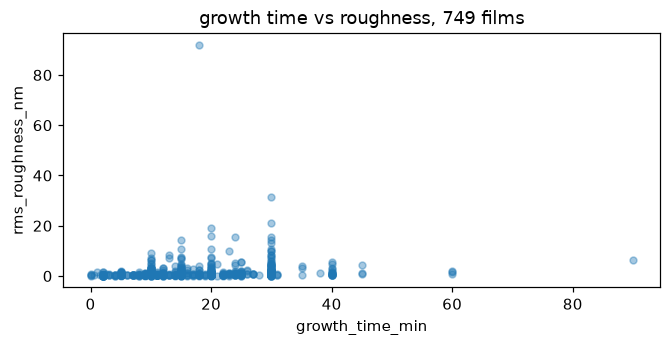

In [6]:
from ipywidgets import Dropdown

FEW = ["material", "growth_time_min", "rms_roughness_nm"]
MORE = FEW + ["growth_method", "growth_temperature_C", "growth_pressure_torr", "scan_size_um"]

@interact(how_many_columns=Dropdown(options=["a few", "all of them"]),
          missing_values=Dropdown(options=["already dealt with", "left in, visible"]),
          scan_sizes=Dropdown(options=["all mixed together", "only the common 5 µm scans"]))
def dials(how_many_columns="a few", missing_values="already dealt with",
          scan_sizes="all mixed together"):
    table = films[FEW if how_many_columns == "a few" else MORE]
    if missing_values == "already dealt with":
        table = table.dropna()
    if scan_sizes.startswith("only"):
        table = table[films["scan_size_um"].between(4.6, 5.4)]

    drawable = table.dropna(subset=["growth_time_min", "rms_roughness_nm"])
    print("%d of %d rows on the table, %d of them drawable on this chart"
          % (len(table), len(films), len(drawable)))
    if len(drawable):
        drawable.plot.scatter(x="growth_time_min", y="rms_roughness_nm", alpha=0.4, figsize=(7, 3),
                              title="growth time vs roughness, %d films" % len(drawable))
    display(table.head())

Turning a dial changes how many rows you have left, and the chart says so every time. That is the
honest version of "simplify the data for younger students": you are not making the science
easier, you are deciding how much of the mess to carry, and admitting what it costs.

One caution to pass on with it: a pattern here is an **association**, not a cause. These are
records of what a lab happened to grow, not an experiment where anything was held fixed.

## 6. Your turn

Change one thing. Some starting points, roughly in order of effort:

- Colour the scatter by `material` and see whether one material drives the whole pattern.
- Swap `growth_time_min` for `growth_temperature_C` on the x axis. Watch what happens — the
  temperature column has only 13 distinct values, so the picture is stripes, not a cloud. That
  is a real lesson about when a scatter plot is the wrong chart.
- Add a dropdown that picks which material to look at.
- Replace the histogram with a box plot per growth method.

The cell below is a copy of the slider from section 3, ready to be broken.

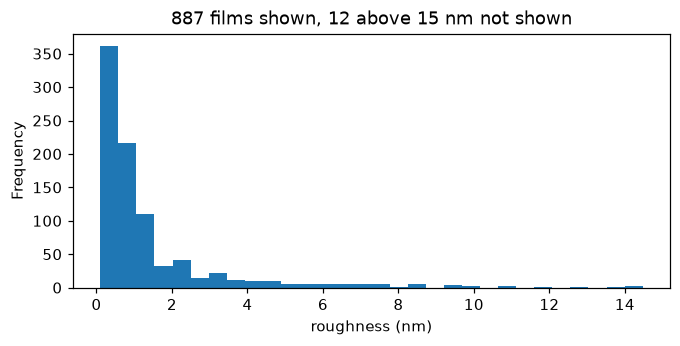

In [7]:
@interact(cut_off_at=(2, 92, 2))
def your_version(cut_off_at=15):
    kept = films[films["rms_roughness_nm"] <= cut_off_at]
    kept["rms_roughness_nm"].plot.hist(bins=30, figsize=(7, 3))
    plt.title("your turn: %d films of %d" % (len(kept), len(films)))